In [196]:
import pypsa
import numpy as np
import matplotlib.pyplot as plt

In [197]:
from _helpers_notebooks import mock_snakemake

snakemake = mock_snakemake(
    "plot_compare_lcox",
    wacc="regional",  # uniform or regional
    cost_year="2050",
    trade_chain="supplyconstraint",  # default, mga-stability-weighted, mga-chokepoints, mga-blocs, constrain-supply
)

In [198]:
config = snakemake.config

In [199]:
add_iron_ore_cost = True

In [200]:
colors = config["colors"]

### Read networks in Network collection

In [201]:
low_cost = snakemake.params.low_cost
high_cost = snakemake.params.high_cost
quantities = snakemake.params.quantities
comparison = snakemake.params.comparison

# Build ordered (region, qty) pairs matching the expand() order in the rule:
# low_cost regions first, then high_cost, each with all quantities
region_qty_pairs = [(r, q) for r in low_cost + high_cost for q in quantities]

# Map scenario key → file path (supply_networks list is in the same expansion order)
supply_files = list(snakemake.input.supply_networks)
scenario_file_map = {
    f"{region}_{qty}": supply_files[i]
    for i, (region, qty) in enumerate(region_qty_pairs)
}
scenarios = list(scenario_file_map.keys())

In [202]:
nc = {}

for scenario, model_fn in scenario_file_map.items():
    n = pypsa.Network(model_fn)
    n.name = scenario
    nc[scenario] = n

nc = pypsa.NetworkCollection(list(nc.values()))

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'LCOX-East_Asia-hbi-1.0' has buses, carriers, generators, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'LCOX-East_Asia-hbi-10.0' has buses, carriers, generators, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'LCOX-East_Asia-hbi-100.0' has buses, carriers, generators, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'LCOX-South_America-hbi-1.0' has buses, carriers, generators, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'LCOX-South_America-hbi-10.0' has buses, carriers, generators, links, loads, stores, s

### Adjust carrier name before statistics

In [203]:
# Rename for all scenarios
for scenario in scenarios:
    nc[scenario].links["carrier"] = nc[scenario].links["carrier"].replace({
        "battery_elec": "battery discharge",
        "renewable_electricity": "battery charge"
    })

### Costs

In [204]:
hbi_demand = nc.statistics.withdrawal().to_frame().loc["Load", :, "hbi_demand"]
# hbi_demand

In [205]:
df = nc.statistics.system_cost(groupby="carrier").to_frame("systemcost")
# df

In [206]:
fom = nc.statistics.fom(groupby="carrier").to_frame("fom")

In [207]:
df["systemcost+fom"] = df["systemcost"].add(fom["fom"], fill_value=0)

In [208]:
df["systemcost+fom_per_hbi"] = df["systemcost+fom"].div(hbi_demand.squeeze().rename_axis("network"), level="network")
# df

### Iron ore

In [209]:
iron_ore_cost = config["iron_ore"]["marginal_cost"] * config["iron_ore"]["ore_to_steel_ratio"] 

### Transport cost (from trade model)

In [210]:
# Read the trade network solely to extract shipping costs.
# This network is NOT added to the supply-chain NetworkCollection.
n_trade = pypsa.Network(snakemake.input.trade_result)

# For each low_cost region compute the per-unit shipping cost to the first
# high_cost region in the comparison pair (comparison[0]).
# Shipping links have carrier=="shipping_hbi", bus0="{origin}_hbi", bus1="{dest}_hbi".
comp_dest = comparison[0]  # e.g. "Europe"

transport_costs = {}  # {region_key: €/unit_hbi}
for low_region in low_cost:
    link_mask = (
        (n_trade.links.carrier == "shipping_hbi")
        & (n_trade.links.bus0 == f"{low_region}_hbi")
        & (n_trade.links.bus1 == f"{comp_dest}_hbi")
    )
    shipping_links = n_trade.links[link_mask]
    if not shipping_links.empty:
        # marginal_cost is in the same €/unit units as the supply-chain optimisation
        transport_costs[low_region] = float(shipping_links.marginal_cost.mean())
    else:
        transport_costs[low_region] = 0.0

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, sub_networks


### Plot

In [211]:
def region_display_name(region):
    """Convert config region key (e.g. 'South_America') to display name ('South America')."""
    return region.replace("_", " ")

def parse_scenario(name):
    """Split a scenario key like 'South_America_10' into (display_name, qty_float)."""
    region, qty_raw = name.rsplit("_", 1)
    return region_display_name(region), float(qty_raw)

# --- Build pivot table of costs ---
plot_df = df.pivot_table(
    index="network", columns="carrier", values="systemcost+fom_per_hbi", aggfunc="sum"
)

if add_iron_ore_cost:
    plot_df["iron ore"] = iron_ore_cost
else:
    plot_df["iron ore"] = 0

plot_df.rename(
    columns={
        "renewable_solar": "solar",
        "renewable_onwind": "onshore wind",
        "battery charge": "battery inverter (charging)",
        "battery discharge": "battery inverter (discharging)",
        "battery_elec": "battery",
        "hydrogen": "hydrogen storage",
        "electrolysis": "electrolysis",
        "direct_reduction_furnace": "direct reduction furnace",
    },
    inplace=True,
)

order = [
    "iron ore", "solar", "onshore wind",
    "battery inverter (charging)", "battery inverter (discharging)",
    "battery", "hydrogen storage", "electrolysis", "direct reduction furnace",
]
plot_df = plot_df[[c for c in order if c in plot_df.columns]]

# --- Attach region / quantity metadata from params ---
plot_df["region"] = [parse_scenario(s)[0] for s in plot_df.index]
plot_df["quantity"] = [parse_scenario(s)[1] for s in plot_df.index]

# --- Add shipping cost for low_cost regions (0 for high_cost regions) ---
low_cost_display = {region_display_name(r): transport_costs.get(r, 0.0) for r in low_cost}
plot_df["shipping"] = plot_df["region"].map(low_cost_display).fillna(0.0)

# --- Sort: low_cost regions left, high_cost regions right; within group by qty ---
groups_ordered = (
    [region_display_name(r) for r in low_cost]
    + [region_display_name(r) for r in high_cost]
)
plot_df["region_order"] = plot_df["region"].map({g: i for i, g in enumerate(groups_ordered)})
plot_df = plot_df.sort_values(["region_order", "quantity"]).drop(columns="region_order")

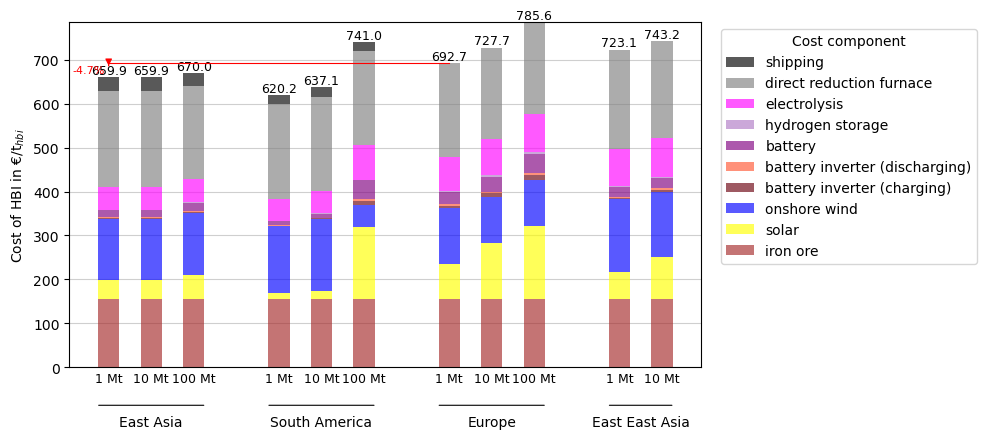

In [212]:
# --- Column order: supply-chain components then shipping on top ---
supply_order = [c for c in order if c in plot_df.columns]
show_shipping = (plot_df["shipping"] > 0).any()
plot_cols = supply_order + (["shipping"] if show_shipping else [])

# --- Colors: extend config colors with a shipping entry ---
plot_colors = dict(config["colors"])
plot_colors.setdefault("shipping", plot_colors.get("shipping", "#6495ED"))

# --- Compute x positions with a gap between region groups ---
bar_width = 0.5
group_gap = 1

x_positions = []
group_centers = {}
group_spans = {}
current_x = 0

for g in groups_ordered:
    mask = plot_df["region"] == g
    n_bars = int(mask.sum())
    positions = list(range(current_x, current_x + n_bars))
    x_positions.extend(positions)
    group_centers[g] = np.mean(positions)
    group_spans[g] = (positions[0], positions[-1])
    current_x += n_bars + group_gap

# --- Create stacked bar plot ---
fig, ax = plt.subplots(figsize=(10, 4.5))

bottom = np.zeros(len(plot_df))
for col in plot_cols:
    values = plot_df[col].fillna(0).values
    ax.bar(x_positions, values, bottom=bottom, width=bar_width,
           label=col, color=plot_colors[col], alpha=0.65)
    bottom += values

# --- Totals on top of bars ---
totals = plot_df[plot_cols].sum(axis=1).values
for x, total in zip(x_positions, totals):
    ax.text(x, total, f"{total:.1f}", ha="center", va="bottom", fontsize=9)

# --- Primary axis formatting ---
ax.set_ylabel("Cost of HBI in €/t$_{hbi}$")
ax.set_xlabel("")
ax.yaxis.grid(True, linestyle="-", alpha=0.6)
ax.set_axisbelow(True)

# --- Inner x-axis: quantity labels ---
ax.set_xticks(x_positions)
qty_labels = [f"{row['quantity']:.4g} Mt" for _, row in plot_df.iterrows()]
ax.set_xticklabels(qty_labels, rotation=0, fontsize=9)
ax.tick_params(axis="x", length=0)

# --- Outer x-axis: region group labels with bracket ---
xaxis_transform = ax.get_xaxis_transform()
y_bracket = -0.11
y_label_pts = -7

for g in groups_ordered:
    center = group_centers[g]
    x_start, x_end = group_spans[g]

    ax.annotate(
        "",
        xy=(x_end + bar_width / 2 + 0.05, y_bracket),
        xycoords=xaxis_transform,
        xytext=(x_start - bar_width / 2 - 0.05, y_bracket),
        textcoords=xaxis_transform,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
        annotation_clip=False,
    )
    ax.annotate(
        g,
        xy=(center, y_bracket),
        xycoords=xaxis_transform,
        xytext=(0, y_label_pts),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10,
        annotation_clip=False,
    )

# --- % difference annotation between the comparison pair ---
# comparison[0] is the high-cost baseline, comparison[1] is the low-cost target
comp_high_display = region_display_name(comparison[0])
comp_low_display  = region_display_name(comparison[1])

plot_df_idx_list = list(plot_df.index)
high_first = plot_df[plot_df["region"] == comp_high_display].index[0]
low_first  = plot_df[plot_df["region"] == comp_low_display].index[0]

high_first_xpos = x_positions[plot_df_idx_list.index(high_first)]
low_first_xpos  = x_positions[plot_df_idx_list.index(low_first)]

totals_series = plot_df[plot_cols].sum(axis=1)
y_high_top = float(totals_series[high_first])
y_low_top  = float(totals_series[low_first])

# Negative pct_diff means the low-cost region is cheaper than the baseline
pct_diff = (y_low_top - y_high_top) / y_high_top * 100

# Horizontal reference line at high-cost level spanning across to the low-cost bar
ax.plot([low_first_xpos, high_first_xpos], [y_high_top, y_high_top],
        color="red", linewidth=0.8, clip_on=False, zorder=5)

# Downward arrow from high-cost level to low-cost bar top
ax.annotate(
    "",
    xy=(low_first_xpos, y_low_top + 20),
    xytext=(low_first_xpos, y_high_top),
    arrowprops=dict(arrowstyle="-|>", color="red", lw=0.8),
    annotation_clip=False,
)

ax.text(
    low_first_xpos - 0.1,
    (y_high_top + y_low_top) / 2,
    f"{pct_diff:.1f}%",
    ha="right",
    va="center",
    fontsize=8,
    color="red",
)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Cost component",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.savefig(snakemake.output.lcox_comparison, dpi=300, bbox_inches="tight")
plt.savefig(snakemake.output.lcox_comparison_png, dpi=300, bbox_inches="tight")
plt.show()

<!-- ### Statistics clarifiction (to be deleted) -->

In [213]:
# nc["europe_100"].objective / 1e6

In [214]:
# system_cost = nc["europe_100"].statistics.system_cost().div(1e6).sum()
# system_cost.round(2)

In [215]:
# fom = nc["europe_100"].statistics.fom().div(1e6).sum()
# fom.round(2)

In [216]:
# expanded_capex = nc["eu_1"].statistics.expanded_capex().div(1e6).sum()
# expanded_capex.round(2)

In [217]:
# opex = nc["eu_1"].statistics.opex().div(1e6).sum()
# opex.round(2)

<!-- -> system_cost = expanded_capex + opex -->

In [218]:
# objective = nc["eu_1"].objective / 1e6
# objective.round(2)

<!-- -> objective = system_cost + fom = expanded_capex + opex + fom -->

In [219]:
# nc["eu_1"].statistics.overnight_cost().div(1e6).sum()